In [34]:
import torch
from torch import nn
from torchmetrics.classification import MulticlassAccuracy
import tqdm
import numpy as np
import pandas as pd

In [2]:
from torchvision import datasets, transforms

transform = transforms.ToTensor()

train_dataset = datasets.MNIST(
    root="./data",
    train=True,
    download=False,
    transform=transform
)

test_dataset = datasets.MNIST(
    root="./data",
    train=False,
    download=False,
    transform=transform
)

In [3]:
image, label = test_dataset[0]
image.view(-1, 784).shape

torch.Size([1, 784])

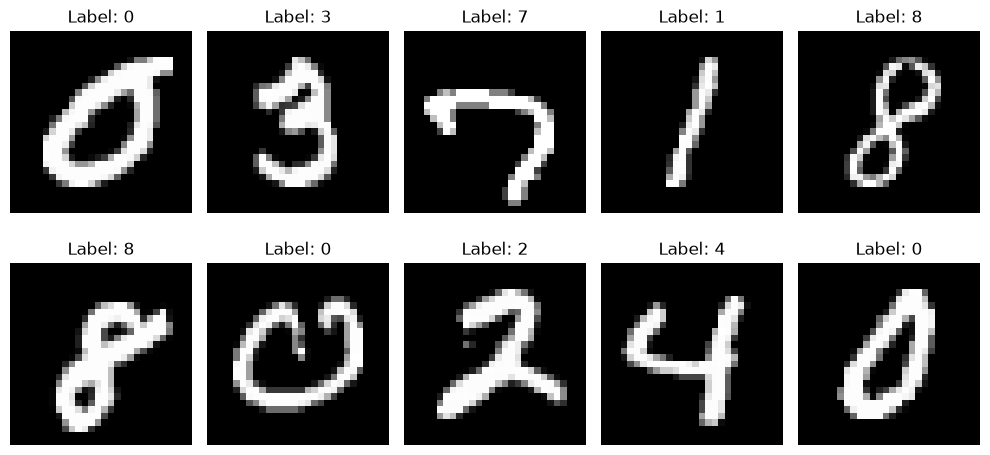

In [4]:
import random
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 5, figsize=(10, 5))

for ax in axes.flat:
    index = random.randint(0, len(test_dataset) - 1)

    image, label = test_dataset[index]

    ax.imshow(image.squeeze(), cmap="gray")
    ax.set_title(f"Label: {label}")
    ax.axis("off")

plt.tight_layout()
plt.show()

In [5]:
X_train = []
X_test = []
y_train = []
y_test = []

In [6]:
print("Adding data")
for image, label in tqdm.tqdm(train_dataset):
    X_train.append(image.view(-1, 784))
    y_train.append(label)

print("Done")

Adding data


100%|██████████| 60000/60000 [00:05<00:00, 10664.58it/s]

Done


In [7]:
print("Adding data")
for image, label in tqdm.tqdm(test_dataset):
    X_test.append(image.view(-1, 784))
    y_test.append(label)

print("Done")

Adding data


100%|██████████| 10000/10000 [00:00<00:00, 10783.55it/s]

Done


In [8]:
X_train = torch.stack(X_train)
y_train = torch.tensor(y_train)
X_test = torch.stack(X_test)
y_test = torch.tensor(y_test)

X_train.shape, y_train.shape, X_test.shape, y_test.shape

(torch.Size([60000, 1, 784]),
 torch.Size([60000]),
 torch.Size([10000, 1, 784]),
 torch.Size([10000]))

In [12]:
df = pd.DataFrame({"label": y_test})
df["label"].unique()

array([7, 2, 1, 0, 4, 9, 5, 6, 3, 8])

In [22]:
random_seed = 42
device = "cuda" if torch.cuda.is_available() else "cpu"

In [43]:
def plot_loss(epochs, train_loss, test_loss):
    plt.plot(epochs, train_loss, label="Train loss")
    plt.plot(epochs, test_loss, label="Test loss")
    plt.title("Training and testing loss curves")
    plt.ylabel("Loss")
    plt.xlabel("Epochs")
    plt.legend()
    plt.show()

In [14]:
hidden_layers = 2
neurons_per_hl = 16

In [72]:


class CharacterRecognitionModel(nn.Module):
    def __init__(self, hidden_layers, neurons_per_hl):
        super().__init__()

        layers = [nn.Linear(in_features=784, out_features=neurons_per_hl), nn.ReLU()]

        for i in range(hidden_layers):
            layers.append(nn.Linear(in_features=16, out_features=16))
            layers.append(nn.ReLU())

        layers.append(nn.Linear(in_features=neurons_per_hl, out_features=10))

        print(layers)
        self.layers = nn.Sequential(*layers)

    def forward(self, x):
        return self.layers(x)

torch.manual_seed(random_seed)

model = CharacterRecognitionModel(hidden_layers=hidden_layers, neurons_per_hl=neurons_per_hl)

[Linear(in_features=784, out_features=16, bias=True), ReLU(), Linear(in_features=16, out_features=16, bias=True), ReLU(), Linear(in_features=16, out_features=16, bias=True), ReLU(), Linear(in_features=16, out_features=10, bias=True)]


In [73]:
model

CharacterRecognitionModel(
  (layers): Sequential(
    (0): Linear(in_features=784, out_features=16, bias=True)
    (1): ReLU()
    (2): Linear(in_features=16, out_features=16, bias=True)
    (3): ReLU()
    (4): Linear(in_features=16, out_features=16, bias=True)
    (5): ReLU()
    (6): Linear(in_features=16, out_features=10, bias=True)
  )
)

In [74]:
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(params=model.parameters(), lr=0.01)

accuracy_fn = MulticlassAccuracy(num_classes=10)

In [75]:
epoch_count = []
train_loss_count = []
test_loss_count = []

In [76]:
# training loop
epochs = 200

X_train.to(device=device)
y_train.to(device=device)
X_test.to(device=device)
y_test.to(device=device)

for epoch in range(epochs):
    model.train()

    epoch_count.append(epoch)

    x_logits = model(X_train).squeeze()
    # print(x_logits.shape)
    x_preds = torch.softmax(x_logits, dim=1).argmax(dim=1)
    # print(x_preds.shape)

    train_loss = loss_fn(x_logits, y_train)
    train_loss_count.append(train_loss.detach().numpy())

    train_acc = accuracy_fn(x_preds, y_train)

    optimizer.zero_grad()
    train_loss.backward()
    optimizer.step()

    model.eval()
    with torch.inference_mode():
        y_logits = model(X_test).squeeze()
        y_preds = torch.softmax(y_logits, dim=1).argmax(dim=1)

        test_loss = loss_fn(y_logits, y_test)
        test_loss_count.append(test_loss.detach().numpy())

        test_acc = accuracy_fn(y_preds, y_test)

    if epoch % 10 == 0:
        print(f"Epoch: {epoch} | Train_loss: {train_loss} | Train_acc: {train_acc} | Test_loss: {test_loss} | Test_acc: {test_acc}")




Epoch: 0 | Train_loss: 2.3135364055633545 | Train_acc: 0.10000000149011612 | Test_loss: 2.3150978088378906 | Test_acc: 0.10000000149011612
Epoch: 10 | Train_loss: 2.313056707382202 | Train_acc: 0.10000000149011612 | Test_loss: 2.3145906925201416 | Test_acc: 0.10000000149011612
Epoch: 20 | Train_loss: 2.31257963180542 | Train_acc: 0.10000000149011612 | Test_loss: 2.3140852451324463 | Test_acc: 0.10000000149011612
Epoch: 30 | Train_loss: 2.3121044635772705 | Train_acc: 0.10000000149011612 | Test_loss: 2.3135812282562256 | Test_acc: 0.10000000149011612
Epoch: 40 | Train_loss: 2.311631917953491 | Train_acc: 0.10000000149011612 | Test_loss: 2.313079357147217 | Test_acc: 0.10000000149011612
Epoch: 50 | Train_loss: 2.311161756515503 | Train_acc: 0.10000000149011612 | Test_loss: 2.312579870223999 | Test_acc: 0.10000000149011612
Epoch: 60 | Train_loss: 2.310694694519043 | Train_acc: 0.10000000149011612 | Test_loss: 2.3120839595794678 | Test_acc: 0.10000000149011612
Epoch: 70 | Train_loss: 2.310

In [77]:
model.eval()
with torch.inference_mode():
    predictions = model(X_test).squeeze()

predictions.shape, (torch.softmax(predictions, dim=1).argmax(dim=1) == y_test)[:20]

(torch.Size([10000, 10]),
 tensor([ True, False, False, False, False, False, False, False, False, False,
         False, False, False, False, False, False, False,  True, False, False]))

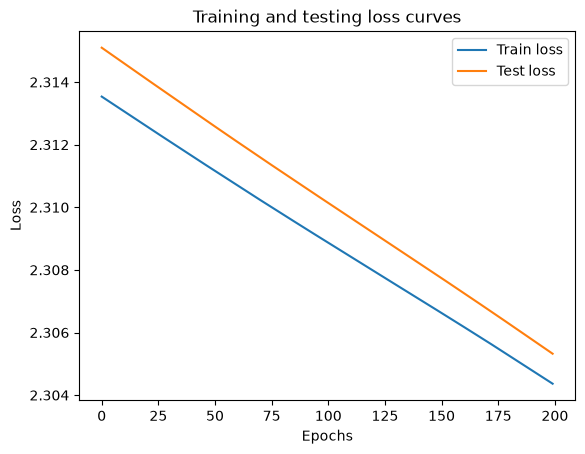

In [78]:
plot_loss(epoch_count, train_loss_count, test_loss_count)